In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_parquet(r'D:\pythonProject\itransformer-walkforward\data\raw\BTCUSDT_1h.parquet')
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 75094 entries, 2018-01-01 00:00:00+00:00 to 2026-07-31 23:00:00+00:00
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   open             75094 non-null  float64            
 1   high             75094 non-null  float64            
 2   low              75094 non-null  float64            
 3   close            75094 non-null  float64            
 4   volume           75094 non-null  float64            
 5   close_time       75094 non-null  datetime64[ms, UTC]
 6   quote_volume     75094 non-null  float64            
 7   trades           75094 non-null  int64              
 8   taker_buy_base   75094 non-null  float64            
 9   taker_buy_quote  75094 non-null  float64            
dtypes: datetime64[ms, UTC](1), float64(8), int64(1)
memory usage: 6.3 MB


In [4]:
df.isna().sum().sort_values(ascending=True)

open               0
high               0
low                0
close              0
volume             0
close_time         0
quote_volume       0
trades             0
taker_buy_base     0
taker_buy_quote    0
dtype: int64

In [5]:
df.head()

,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base,taker_buy_quote
open_time,,,,,,,,,,
2018-01-01 00:00:00+00:00,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999000+00:00,5.993910e+06,5228,228.521921,3.090541e+06
2018-01-01 01:00:00+00:00,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999000+00:00,5.154522e+06,4534,180.840403,2.430449e+06
2018-01-01 02:00:00+00:00,13203.00,13418.43,13200.00,13330.18,429.064572,2018-01-01 02:59:59.999000+00:00,5.710192e+06,4887,192.237935,2.558505e+06
2018-01-01 03:00:00+00:00,13330.26,13611.27,13290.00,13410.03,420.087030,2018-01-01 03:59:59.999000+00:00,5.657448e+06,4789,137.918407,1.858041e+06
2018-01-01 04:00:00+00:00,13434.98,13623.29,13322.15,13601.01,340.807329,2018-01-01 04:59:59.999000+00:00,4.588047e+06,4563,172.957635,2.328058e+06


In [6]:
df.tail()

,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base,taker_buy_quote
open_time,,,,,,,,,,
2026-07-31 19:00:00+00:00,63097.57,63158.00,62936.29,62972.00,304.88916,2026-07-31 19:59:59.999000+00:00,1.921286e+07,71207,159.90572,1.007626e+07
2026-07-31 20:00:00+00:00,62972.00,63034.00,62928.35,62953.70,318.42027,2026-07-31 20:59:59.999000+00:00,2.005549e+07,59333,164.89602,1.038563e+07
2026-07-31 21:00:00+00:00,62953.70,63062.47,62846.00,62947.78,334.75985,2026-07-31 21:59:59.999000+00:00,2.108927e+07,64578,162.00917,1.020666e+07
2026-07-31 22:00:00+00:00,62947.77,63020.00,62870.01,62950.00,440.99494,2026-07-31 22:59:59.999000+00:00,2.776980e+07,40268,197.08695,1.240878e+07
2026-07-31 23:00:00+00:00,62950.01,63013.52,62860.64,62887.88,186.49459,2026-07-31 23:59:59.999000+00:00,1.174145e+07,29472,62.58436,3.939753e+06


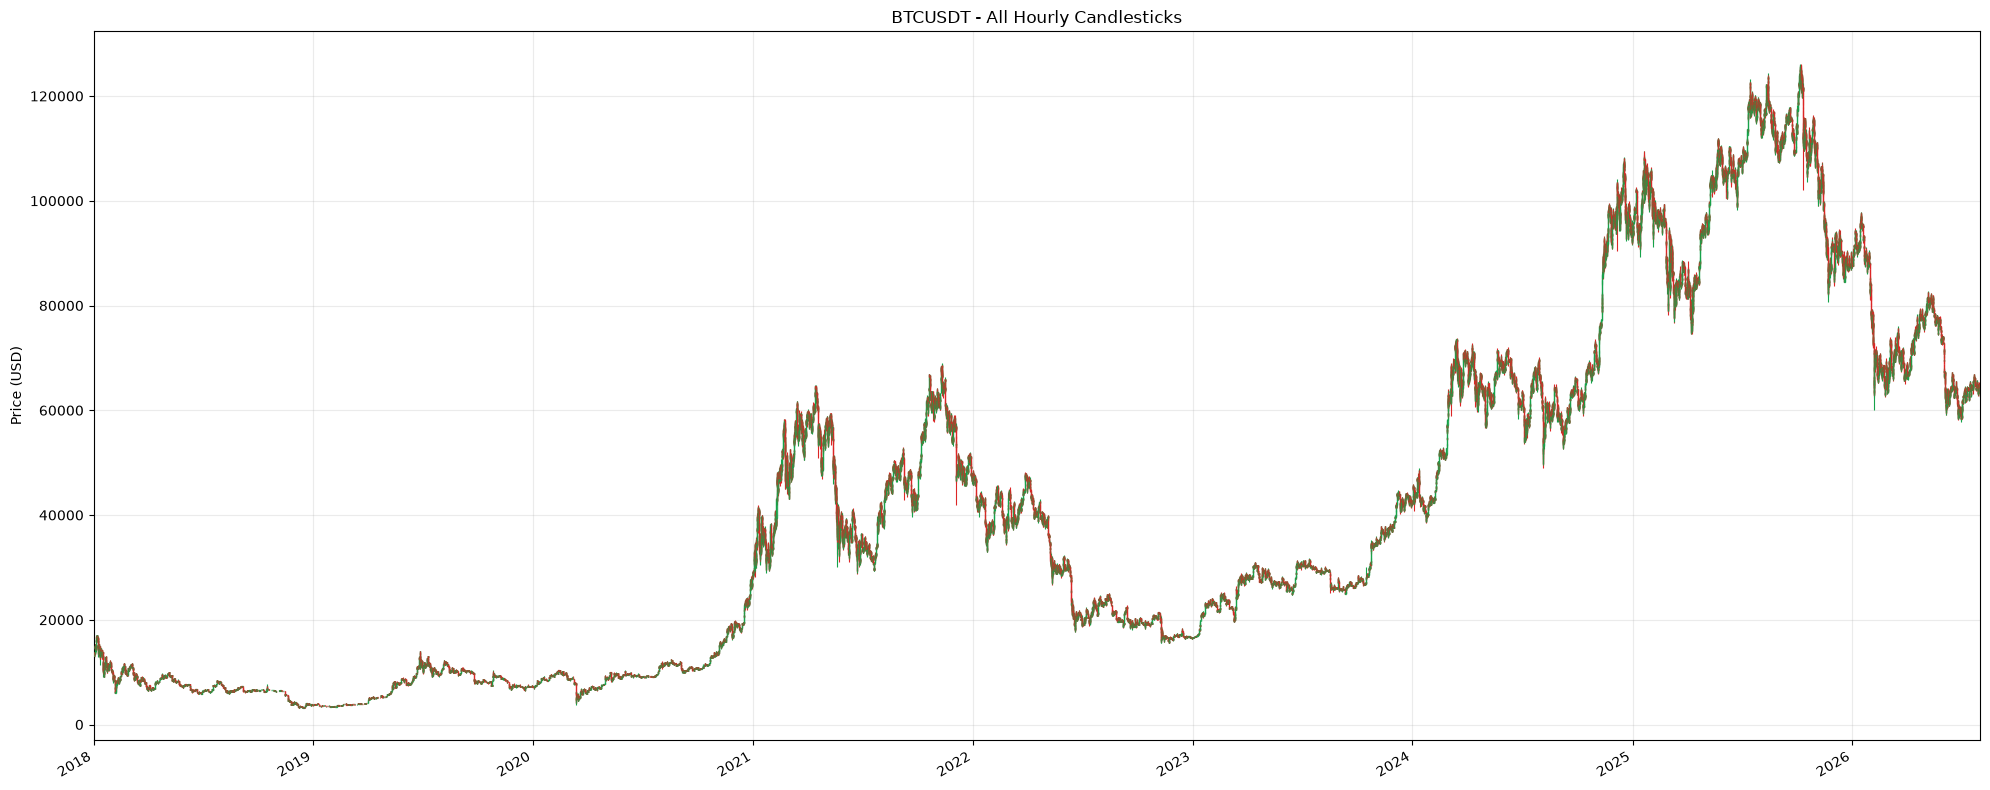

In [7]:
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Use the existing DataFrame `df`
ohlc = df.loc[:, ["open", "high", "low", "close"]].copy()
ohlc.index = pd.to_datetime(ohlc.index)
ohlc = ohlc.sort_index()

x = mdates.date2num(ohlc.index.to_pydatetime())
width = 0.6 * np.median(np.diff(x))

fig, ax = plt.subplots(figsize=(20, 8))

for i in range(len(ohlc)):
    xi = x[i]
    open_i = ohlc["open"].iloc[i]
    close_i = ohlc["close"].iloc[i]
    high_i = ohlc["high"].iloc[i]
    low_i = ohlc["low"].iloc[i]
    color = "#16a34a" if close_i >= open_i else "#dc2626"

    # Wick
    ax.vlines(xi, low_i, high_i, color=color, linewidth=0.8, zorder=2)

    # Body
    body_bottom = min(open_i, close_i)
    body_height = max(abs(close_i - open_i), 1e-9)
    body = Rectangle(
        (xi - width / 2, body_bottom),
        width,
        body_height,
        facecolor=color,
        edgecolor=color,
        alpha=0.8,
        zorder=3
    )
    ax.add_patch(body)

ax.xaxis_date()
ax.set_xlim(x.min() - width, x.max() + width)
ax.set_ylabel("Price (USD)")
ax.set_title("BTCUSDT - All Hourly Candlesticks")
ax.grid(True, alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Feature engineering: famili F1–F5 (12 variat per-bar)

**Aturan segmen.** Bar dengan `volume = 0` atau `high == low` dibuang (tidak ada info transaksi). Seri *putus* di setiap jam yang hilang/dibuang; tanpa imputasi. `r` dihitung di dalam segmen saja, jadi bar pertama tiap segmen dibuang. Tidak ada rolling window: setiap variat hanya membaca bar saat ini (`r` juga membaca close sebelumnya).

Notasi: O, H, L, C = open/high/low/close; V = volume (BTC); Q = quote volume (USDT); N = jumlah trade; B = taker-buy volume (BTC).

| Famili | Variat | Rumus | Makna |
|---|---|---|---|
| F1 Harga | `r` | ln(C / C₋₁) | log-return; **target**, kanal 0 |
| F1 Harga | `upper_shadow` | ln(H / max(O,C)) | panjang sumbu atas candle |
| F1 Harga | `lower_shadow` | ln(min(O,C) / L) | panjang sumbu bawah candle |
| F2 Volatilitas | `log_parkinson` | ln[(ln H/L)² / (4 ln 2)] | volatilitas dari range (Parkinson, 1980) |
| F2 Volatilitas | `log_garman_klass` | ln[½(ln H/L)² − (2 ln 2 − 1)(ln C/O)²] | range + open-close (Garman–Klass, 1980) |
| F2 Volatilitas | `log_rogers_satchell` | ln[ln(H/C)ln(H/O) + ln(L/C)ln(L/O) + 1e-9] | tahan drift (Rogers–Satchell, 1991); +1e-9 karena bernilai 0 pada bar tanpa sumbu |
| F3 Intensitas | `log_quote_volume` | ln Q | nilai transaksi (USDT) |
| F3 Intensitas | `log_trade_count` | ln N | jumlah transaksi |
| F3 Intensitas | `log_mean_trade_size` | ln(Q / N) | rata-rata ukuran transaksi (= selisih dua di atas) |
| F4 Order flow | `taker_buy_ratio` | B / V | porsi volume yang diinisiasi pembeli |
| F4 Order flow | `signed_flow` | (2·B/V − 1) · ln Q | tekanan beli/jual berbobot volume |
| F5 Lokasi | `vwap_location` | (Q/V − C) / (H − L) | posisi VWAP bar relatif terhadap close, dinormalisasi range |

**Tangga K (kumulatif):** K=1 `r` saja → K=4 + shadow & quote volume → K=8 + trade count, order flow, VWAP → K=12 + tiga estimator volatilitas & ukuran trade.


In [8]:
import numpy as np

HOUR = pd.Timedelta(hours=1)
VARIATE_ORDER = [
    "r", "upper_shadow", "lower_shadow", "log_quote_volume",               # K=4
    "log_trade_count", "taker_buy_ratio", "signed_flow", "vwap_location",  # K=8
    "log_parkinson", "log_garman_klass", "log_rogers_satchell", "log_mean_trade_size",  # K=12
]
FAMILY = {
    "r": "F1 harga", "upper_shadow": "F1 harga", "lower_shadow": "F1 harga",
    "log_parkinson": "F2 volatilitas", "log_garman_klass": "F2 volatilitas", "log_rogers_satchell": "F2 volatilitas",
    "log_quote_volume": "F3 intensitas", "log_trade_count": "F3 intensitas", "log_mean_trade_size": "F3 intensitas",
    "taker_buy_ratio": "F4 order flow", "signed_flow": "F4 order flow",
    "vwap_location": "F5 lokasi",
}

# 1) Aturan segmen: buang bar tanpa transaksi, lalu seri putus di tiap lompatan != 1 jam
bars = df.sort_index()
bars = bars[(bars["volume"] > 0) & (bars["high"] > bars["low"])]
seg = (bars.index.to_series().diff() != HOUR).cumsum()

O, H, L, C = bars["open"], bars["high"], bars["low"], bars["close"]
V, Q, N, B = bars["volume"], bars["quote_volume"], bars["trades"], bars["taker_buy_base"]
log_hl, log_co = np.log(H / L), np.log(C / O)

feat = pd.DataFrame(index=bars.index)
# F1 harga (r dihitung per segmen: tidak ada return yang melintasi celah)
feat["r"] = np.log(C).groupby(seg).diff()
feat["upper_shadow"] = np.log(H / np.maximum(O, C))
feat["lower_shadow"] = np.log(np.minimum(O, C) / L)
# F2 volatilitas per-bar
feat["log_parkinson"] = np.log(log_hl**2 / (4 * np.log(2)))
feat["log_garman_klass"] = np.log(0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2)
feat["log_rogers_satchell"] = np.log(np.log(H / C) * np.log(H / O) + np.log(L / C) * np.log(L / O) + 1e-9)
# F3 intensitas
feat["log_quote_volume"] = np.log(Q)
feat["log_trade_count"] = np.log(N)
feat["log_mean_trade_size"] = np.log(Q / N)
# F4 order flow
feat["taker_buy_ratio"] = B / V
feat["signed_flow"] = (2 * feat["taker_buy_ratio"] - 1) * feat["log_quote_volume"]
# F5 lokasi intrabar
feat["vwap_location"] = (Q / V - C) / (H - L)

# Bar pertama tiap segmen tidak punya r
feat = feat.dropna(subset=["r"])[VARIATE_ORDER]
assert np.isfinite(feat.to_numpy()).all(), "ada variat non-finite"

print(f"bar asli {len(df):,} | usable {len(bars):,} | segmen {seg.nunique()} | "
      f"baris fitur {len(feat):,} x {feat.shape[1]} variat")
for k in (1, 4, 8, 12):
    print(f"  K={k:>2}: {VARIATE_ORDER[:k]}")


bar asli 75,094 | usable 75,091 | segmen 29 | baris fitur 75,062 x 12 variat
  K= 1: ['r']
  K= 4: ['r', 'upper_shadow', 'lower_shadow', 'log_quote_volume']
  K= 8: ['r', 'upper_shadow', 'lower_shadow', 'log_quote_volume', 'log_trade_count', 'taker_buy_ratio', 'signed_flow', 'vwap_location']
  K=12: ['r', 'upper_shadow', 'lower_shadow', 'log_quote_volume', 'log_trade_count', 'taker_buy_ratio', 'signed_flow', 'vwap_location', 'log_parkinson', 'log_garman_klass', 'log_rogers_satchell', 'log_mean_trade_size']


In [10]:
feat.head()

,r,upper_shadow,lower_shadow,log_quote_volume,log_trade_count,taker_buy_ratio,signed_flow,vwap_location,log_parkinson,log_garman_klass,log_rogers_satchell,log_mean_trade_size
open_time,,,,,,,,,,,,
2018-01-01 01:00:00+00:00,-0.024388,0.004933,0.003618,15.455385,8.419360,0.471310,-0.886817,0.523877,-7.846114,-8.070295,-8.310434,7.036025
2018-01-01 02:00:00+00:00,0.009582,0.006598,0.000227,15.557763,8.494334,0.448040,-1.616774,-0.099401,-9.239229,-9.218568,-9.123904,7.063429
2018-01-01 03:00:00+00:00,0.005972,0.014895,0.003025,15.548484,8.474077,0.328309,-5.339065,0.178338,-8.488686,-8.211454,-7.992664,7.074407
2018-01-01 04:00:00+00:00,0.014141,0.001637,0.008434,15.338965,8.425736,0.507494,0.229897,-0.460651,-8.621392,-8.560369,-8.529794,6.913229
2018-01-01 05:00:00+00:00,-0.003094,0.006136,0.002399,15.520087,8.534247,0.352105,-4.590687,0.259823,-9.756484,-9.515782,-9.449649,6.985840


,count,mean,std,min,25%,50%,75%,max,famili
r,75062.0,0.000019,0.007166,-0.201033,-0.002387,0.000060,0.002520,0.160280,F1 harga
upper_shadow,75062.0,0.002305,0.002841,0.000000,0.000645,0.001504,0.002966,0.084639,F1 harga
lower_shadow,75062.0,0.002618,0.003614,0.000000,0.000704,0.001652,0.003284,0.160832,F1 harga
log_quote_volume,75062.0,17.480573,1.216753,11.157048,16.618060,17.558600,18.373165,21.823754,F3 intensitas
log_trade_count,75062.0,10.730145,1.176493,3.526361,9.900383,10.753061,11.572868,15.074042,F3 intensitas
taker_buy_ratio,75062.0,0.496209,0.060480,0.113141,0.462156,0.496517,0.530274,0.821413,F4 order flow
signed_flow,75062.0,-0.148848,2.090003,-14.593247,-1.325752,-0.124015,1.045818,11.595315,F4 order flow
vwap_location,75062.0,-0.008633,0.271695,-0.762606,-0.223690,-0.012406,0.205319,0.849458,F5 lokasi
log_parkinson,75062.0,-10.991205,1.485017,-18.272782,-11.985891,-11.035319,-10.027555,-3.218618,F2 volatilitas
log_garman_klass,75062.0,-10.901882,1.470319,-18.028302,-11.878507,-10.927126,-9.943902,-3.088727,F2 volatilitas


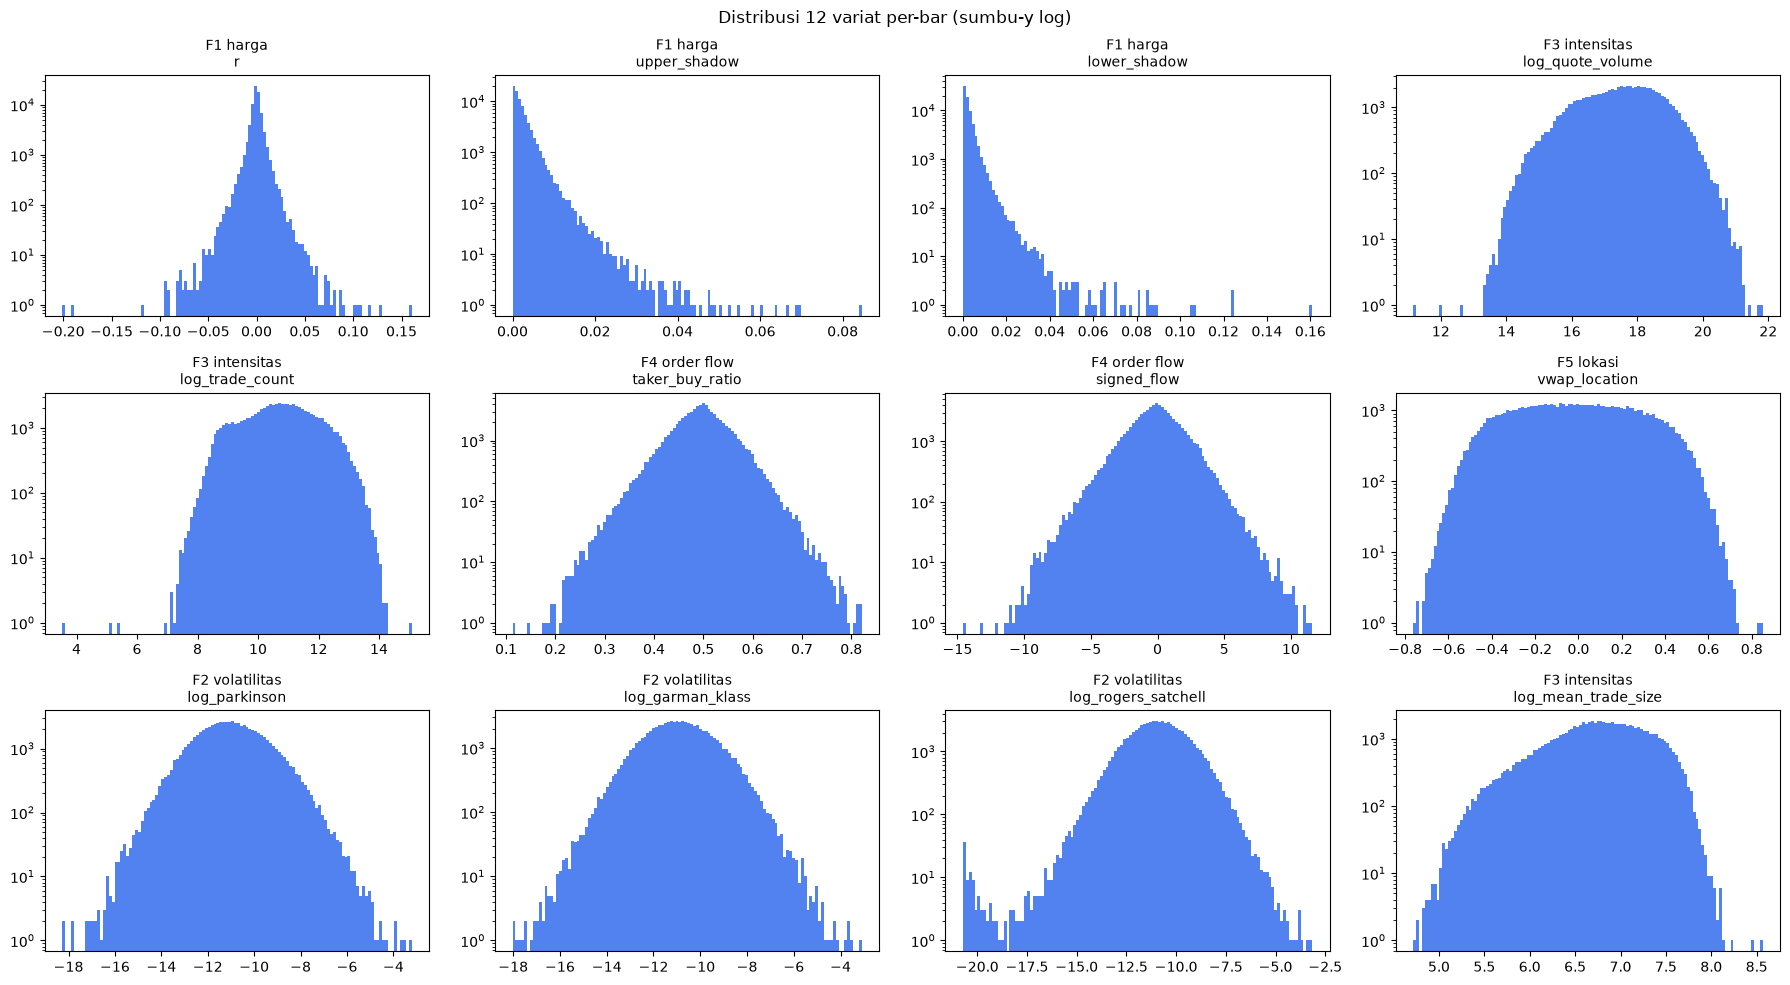

In [9]:
display(feat.describe().T.assign(famili=pd.Series(FAMILY)))

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
for ax, name in zip(axes.ravel(), VARIATE_ORDER):
    ax.hist(feat[name], bins=120, color="#2563eb", alpha=0.8)
    ax.set_title(f"{FAMILY[name]}\n{name}", fontsize=10)
    ax.set_yscale("log")
fig.suptitle("Distribusi 12 variat per-bar (sumbu-y log)")
plt.tight_layout()
plt.show()
